# King County House Price Prediction
### Linear Regression — Real Individual House Sales Data

**Dataset**: King County House Sales (`kc_house_data.csv`) — 21,613 real house sales in Seattle, WA (May 2014 – May 2015)  
**Goal**: Predict individual house sale prices using Linear Regression  
**Tools**: Pandas · NumPy · Matplotlib · Scikit-learn

---

## Table of Contents
1. Import Libraries
2. Load & Clean Data
3. Feature Engineering
4. Exploratory Data Analysis
5. Data Preprocessing
6. Model Building — Linear Regression
7. Model Evaluation
8. Visualize Predictions & Residuals
9. Conclusion

---
## 1. Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.patches import Patch

# ── Dark theme style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e',      'ytick.color':'#8b949e',
    'text.color':'#c9d1d9',       'grid.color':'#21262d',
    'grid.linestyle':'--',        'grid.alpha':0.6,
    'axes.titlesize':13,          'axes.titleweight':'bold',
    'axes.titlecolor':'#f0f6fc',  'font.family':'DejaVu Sans',
})
C1='#58a6ff'; C2='#f78166'; C3='#56d364'; C4='#e3b341'
C5='#bc8cff'; C6='#39d353'; C7='#ff7b72'; C8='#79c0ff'

print('Libraries imported!')

Libraries imported!


---

## 2. Load & Clean Data

| Column | Description |
|--------|-------------|
| `price` | Sale price (target) |
| `bedrooms` / `bathrooms` | Room counts |
| `sqft_living` / `sqft_lot` | Interior & lot size |
| `floors` | Number of floors |
| `waterfront` | Waterfront view flag |
| `view` | Quality of view (0–4) |
| `condition` | Overall condition (1–5) |
| `grade` | King County grading system (1–13) |
| `sqft_above` / `sqft_basement` | Above-ground & basement sqft |
| `yr_built` / `yr_renovated` | Year built & last renovated |
| `lat` / `long` | GPS coordinates |
| `sqft_living15` / `sqft_lot15` | Avg sqft of 15 nearest neighbours |

In [2]:
df = pd.read_csv('kc_house_data.csv')
print(f'Raw shape: {df.shape}')
df.head()

Raw shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [4]:
df.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4.580302e+09,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2.876566e+09,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1.000102e+06,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2.123049e+09,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7.308900e+09,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9.900000e+09,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00


In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
print('Missing values:')
print(df.isnull().sum())

# ── Drop non-predictive columns ───────────────────────────────────────────────
df.drop(columns=['id'], inplace=True)

# ── Parse date ────────────────────────────────────────────────────────────────
df['sale_year']  = df['date'].str[:4].astype(int)
df['sale_month'] = df['date'].str[4:6].astype(int)
df.drop(columns=['date'], inplace=True)

# ── Remove outliers ───────────────────────────────────────────────────────────
print(f'\nBedroom outlier — 33 bedrooms: {(df["bedrooms"]==33).sum()} row(s)')
df = df[df['bedrooms'] <= 10]           # remove data entry error
df = df[df['price'] <= 4_000_000]       # focus on non-ultra-luxury market

print(f'\nCleaned shape: {df.shape}')

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Bedroom outlier — 33 bedrooms: 1 row(s)

Cleaned shape: (21600, 21)


---

## 3. Feature Engineering

We create new features that capture information not directly available in the raw columns:

| New Feature | Formula / Idea |
|-------------|----------------|
| `house_age` | `sale_year − yr_built` |
| `renovated` | 1 if `yr_renovated > 0` |
| `yrs_since_reno` | Years since last renovation |
| `has_basement` | 1 if basement sqft > 0 |
| `sqft_per_bedroom` | Living sqft ÷ bedrooms |
| `bath_per_bed` | Bathrooms ÷ bedrooms |
| `living_lot_ratio` | Living sqft ÷ lot sqft |
| `sqft_living_log` | log(1 + sqft_living) — reduces skew |
| `sqft_lot_log` | log(1 + sqft_lot) — reduces skew |

In [27]:
df['house_age']        = df['sale_year'] - df['yr_built']
df['renovated']        = (df['yr_renovated'] > 0).astype(int)
df['yrs_since_reno']   = np.where(df['yr_renovated'] > 0,
                                   df['sale_year'] - df['yr_renovated'], 0)
df['has_basement']     = (df['sqft_basement'] > 0).astype(int)
df['sqft_per_bedroom'] = df['sqft_living'] / (df['bedrooms'].replace(0, 1))
df['bath_per_bed']     = df['bathrooms']   / (df['bedrooms'].replace(0, 1))
df['living_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)
df['sqft_living_log']  = np.log1p(df['sqft_living'])
df['sqft_lot_log']     = np.log1p(df['sqft_lot'])

print('Features engineered!')
print(f'Total columns: {df.shape[1]}')
df[['house_age','renovated','sqft_per_bedroom','bath_per_bed','living_lot_ratio']].describe().round(2)

Features engineered!
Total columns: 30


,house_age,renovated,sqft_per_bedroom,bath_per_bed,living_lot_ratio
count,21600.00,21600.00,21600.00,21600.00,21600.00
mean,43.32,0.04,618.32,0.64,0.32
std,29.37,0.20,218.14,0.21,0.27
min,-1.00,0.00,163.33,0.00,0.00
25%,18.00,0.00,470.00,0.50,0.16
50%,40.00,0.00,576.67,0.62,0.25
75%,63.00,0.00,722.50,0.75,0.41
max,115.00,1.00,4810.00,2.50,4.64


---

## 4. Exploratory Data Analysis

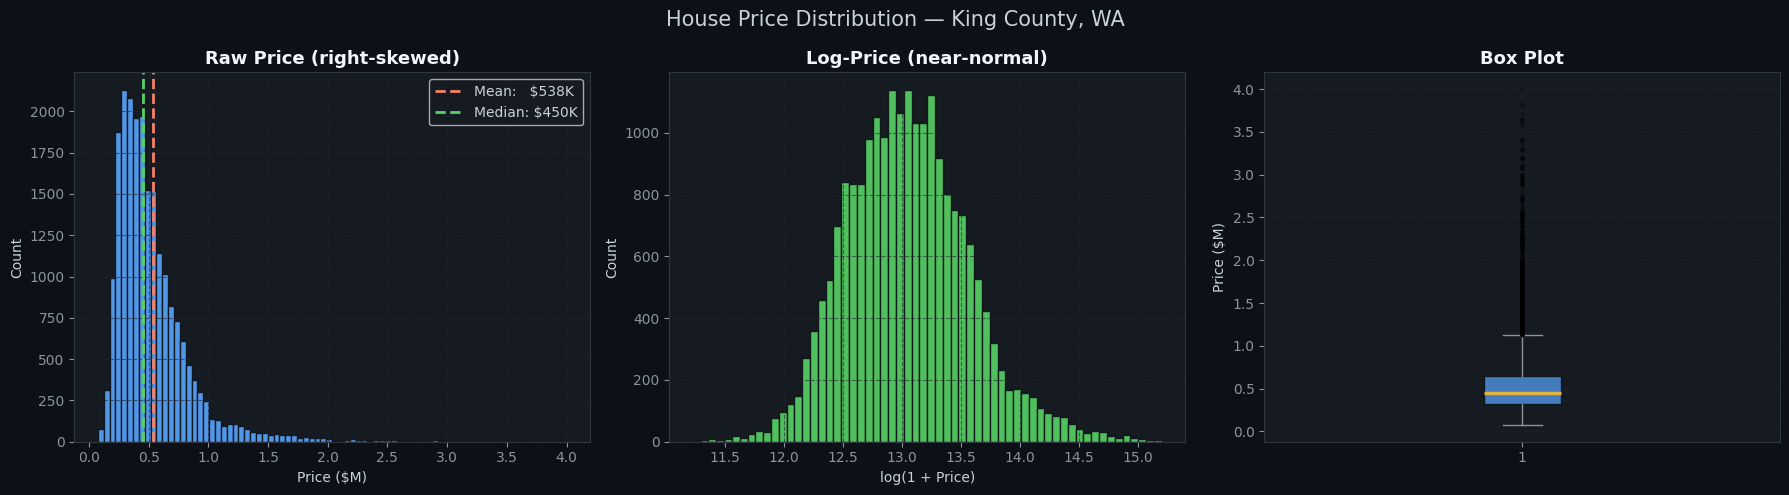

In [7]:
# ── 4.1  Price Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('House Price Distribution — King County, WA', fontsize=15)

ax = axes[0]
ax.hist(df['price']/1e6, bins=80, color=C1, edgecolor='#0d1117', alpha=0.9)
ax.axvline(df['price'].mean()/1e6,   color=C2, lw=2, ls='--',
           label=f'Mean:   ${df["price"].mean()/1e3:.0f}K')
ax.axvline(df['price'].median()/1e6, color=C3, lw=2, ls='--',
           label=f'Median: ${df["price"].median()/1e3:.0f}K')
ax.set_xlabel('Price ($M)'); ax.set_ylabel('Count')
ax.set_title('Raw Price (right-skewed)'); ax.legend(); ax.grid(True)

ax = axes[1]
ax.hist(np.log1p(df['price']), bins=60, color=C3, edgecolor='#0d1117', alpha=0.9)
ax.set_xlabel('log(1 + Price)'); ax.set_ylabel('Count')
ax.set_title('Log-Price (near-normal)'); ax.grid(True)

ax = axes[2]
ax.boxplot(df['price']/1e6, vert=True, patch_artist=True,
           boxprops=dict(facecolor=C1, alpha=0.7),
           medianprops=dict(color=C4, lw=2.5),
           whiskerprops=dict(color='#8b949e'), capprops=dict(color='#8b949e'),
           flierprops=dict(marker='o', color=C2, alpha=0.3, markersize=2))
ax.set_ylabel('Price ($M)'); ax.set_title('Box Plot'); ax.grid(True)

plt.tight_layout(); plt.savefig('plot_01_price_distribution.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

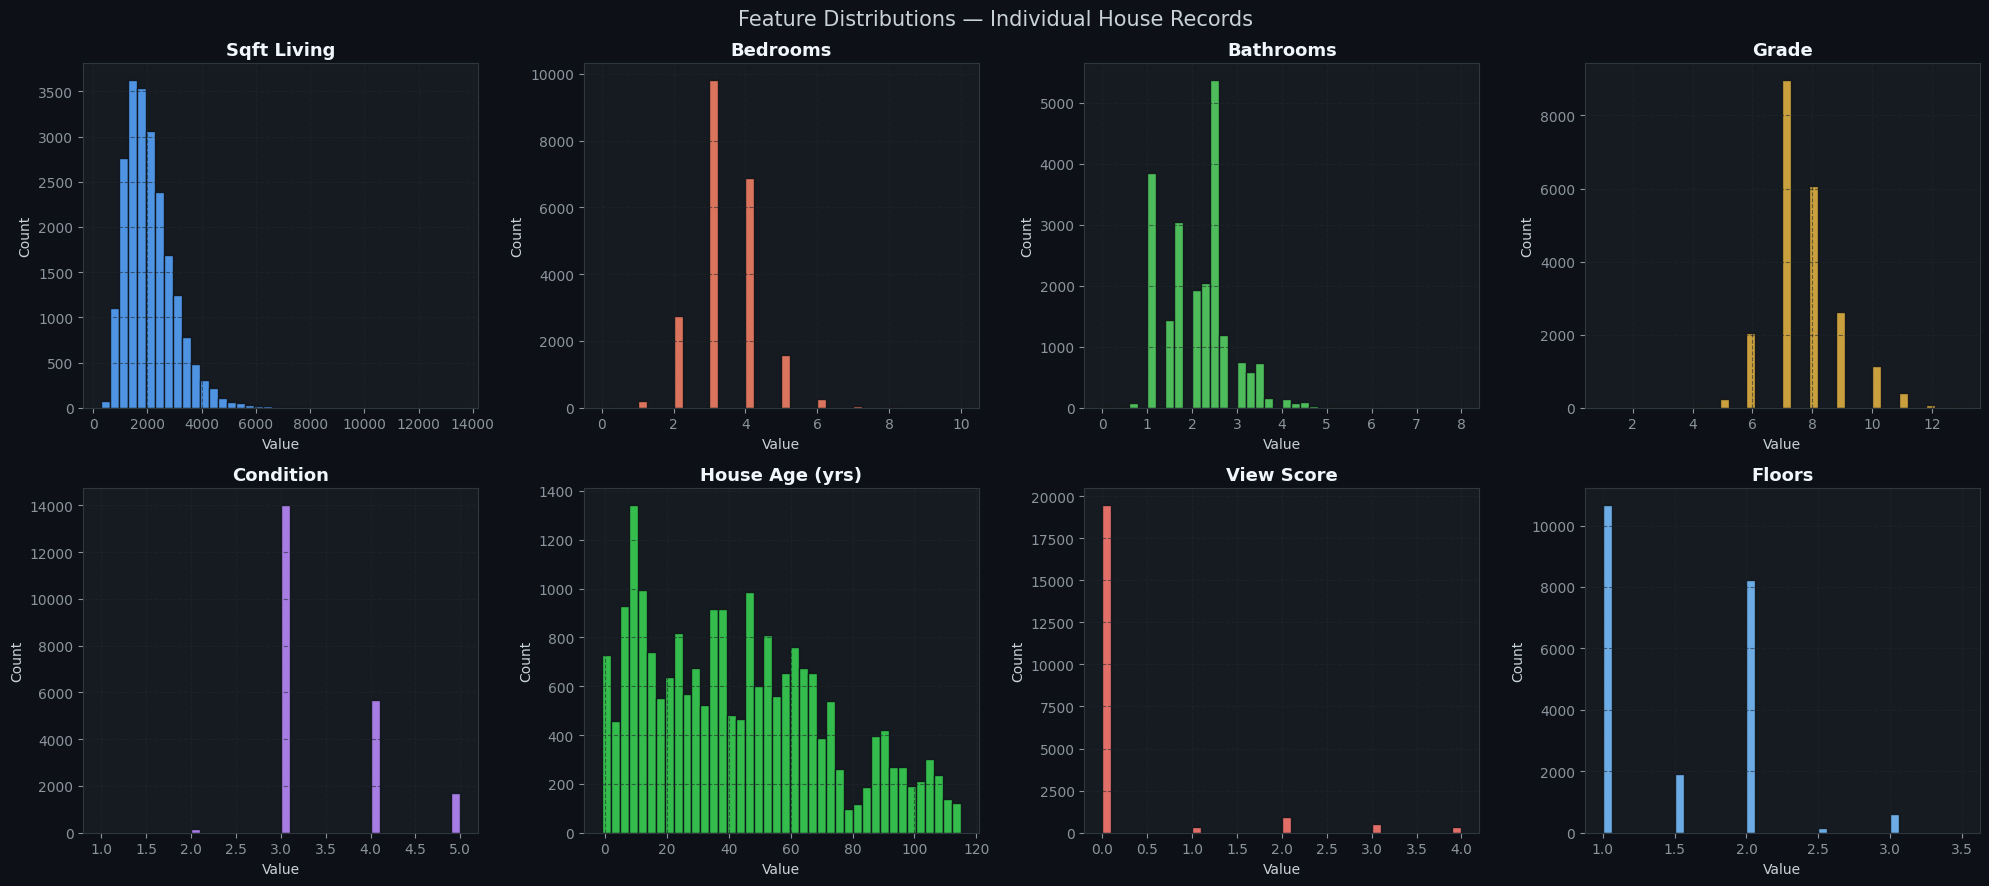

In [8]:
# ── 4.2  Feature Distributions ────────────────────────────────────────────────
feat_plot = [('sqft_living','Sqft Living',C1), ('bedrooms','Bedrooms',C2),
             ('bathrooms','Bathrooms',C3),     ('grade','Grade',C4),
             ('condition','Condition',C5),     ('house_age','House Age (yrs)',C6),
             ('view','View Score',C7),         ('floors','Floors',C8)]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Feature Distributions — Individual House Records', fontsize=15)
for ax, (feat, label, color) in zip(axes.flatten(), feat_plot):
    ax.hist(df[feat], bins=40, color=color, edgecolor='#0d1117', alpha=0.88)
    ax.set_title(label); ax.set_xlabel('Value'); ax.set_ylabel('Count'); ax.grid(True)
plt.tight_layout(); plt.savefig('plot_02_feature_distributions.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

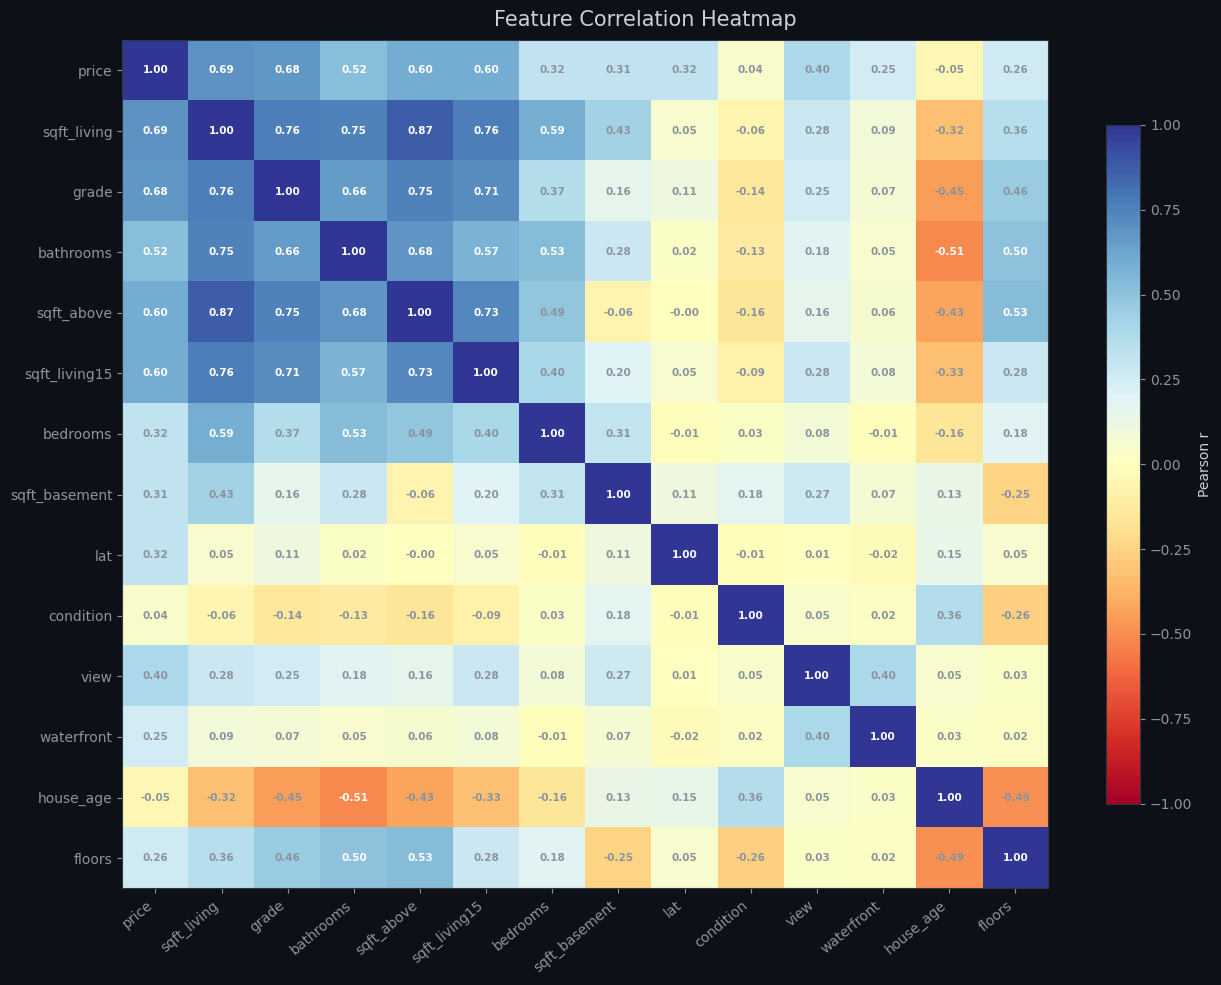


=== Top Correlations with Price ===
  sqft_living        +0.6948  █████████████████
  grade              +0.6774  ████████████████
  sqft_above         +0.5993  ██████████████
  sqft_living15      +0.5972  ██████████████
  bathrooms          +0.5206  █████████████
  view               +0.3965  █████████
  lat                +0.3198  ███████
  bedrooms           +0.3180  ███████
  sqft_basement      +0.3129  ███████
  floors             +0.2639  ██████
  waterfront         +0.2483  ██████
  house_age          -0.0545  █
  condition          +0.0404  █


In [29]:
# ── 4.3  Correlation Heatmap ───────────────────────────────────────────────────
corr_cols = ['price','sqft_living','grade','bathrooms','sqft_above',
             'sqft_living15','bedrooms','sqft_basement','lat',
             'condition','view','waterfront','house_age','floors']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Feature Correlation Heatmap', fontsize=15)
im = ax.imshow(corr.values, cmap='RdYlBu', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
lbs = corr.columns.tolist()
ax.set_xticks(range(len(lbs))); ax.set_yticks(range(len(lbs)))
ax.set_xticklabels(lbs, rotation=40, ha='right'); ax.set_yticklabels(lbs)
for i in range(len(lbs)):
    for j in range(len(lbs)):
        val = corr.values[i,j]
        tc = 'white' if abs(val)>0.5 else '#8b949e'
        ax.text(j,i,f'{val:.2f}',ha='center',va='center',fontsize=7.5,color=tc,fontweight='bold')
plt.tight_layout(); plt.savefig('plot_03_correlation_heatmap.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

print('\n=== Top Correlations with Price ===')
top = corr['price'].drop('price').sort_values(key=abs, ascending=False)
for f,v in top.items():
    print(f'  {f:<18} {v:+.4f}  {"█"*int(abs(v)*25)}')

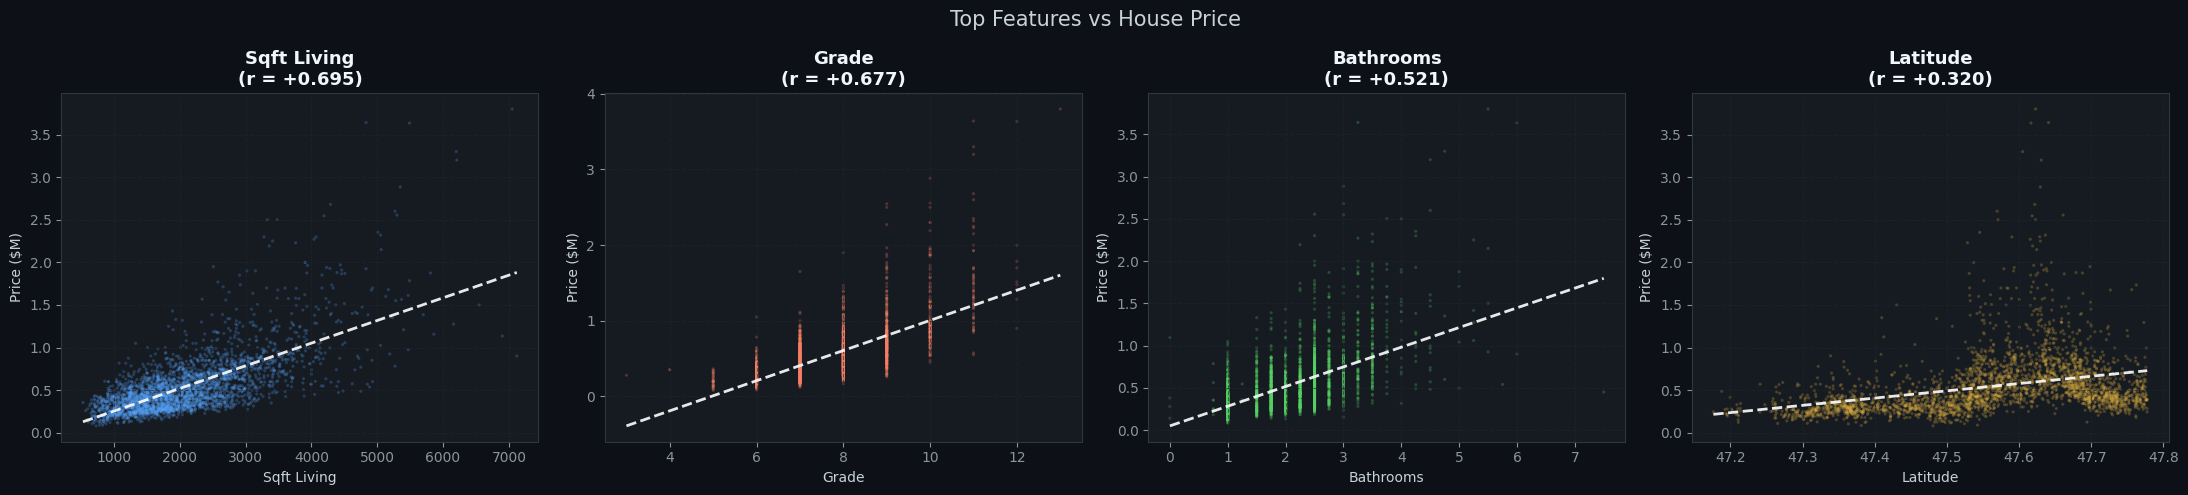

In [10]:
# ── 4.4  Top Features vs Price (scatter) ──────────────────────────────────────
top4 = [('sqft_living','Sqft Living',C1), ('grade','Grade',C2),
        ('bathrooms','Bathrooms',C3),     ('lat','Latitude',C4)]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Top Features vs House Price', fontsize=15)
for ax, (feat, label, color) in zip(axes, top4):
    samp = df.sample(3000, random_state=42)
    ax.scatter(samp[feat], samp['price']/1e6, alpha=0.25, s=5, color=color, edgecolors='none')
    z = np.polyfit(samp[feat], samp['price']/1e6, 1)
    p_fn = np.poly1d(z)
    xl = np.linspace(samp[feat].min(), samp[feat].max(), 300)
    ax.plot(xl, p_fn(xl), color='white', lw=2, ls='--', alpha=0.9)
    r = df[[feat,'price']].corr().iloc[0,1]
    ax.set_title(f'{label}\n(r = {r:+.3f})')
    ax.set_xlabel(label); ax.set_ylabel('Price ($M)'); ax.grid(True)
plt.tight_layout(); plt.savefig('plot_04_scatter_top_features.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

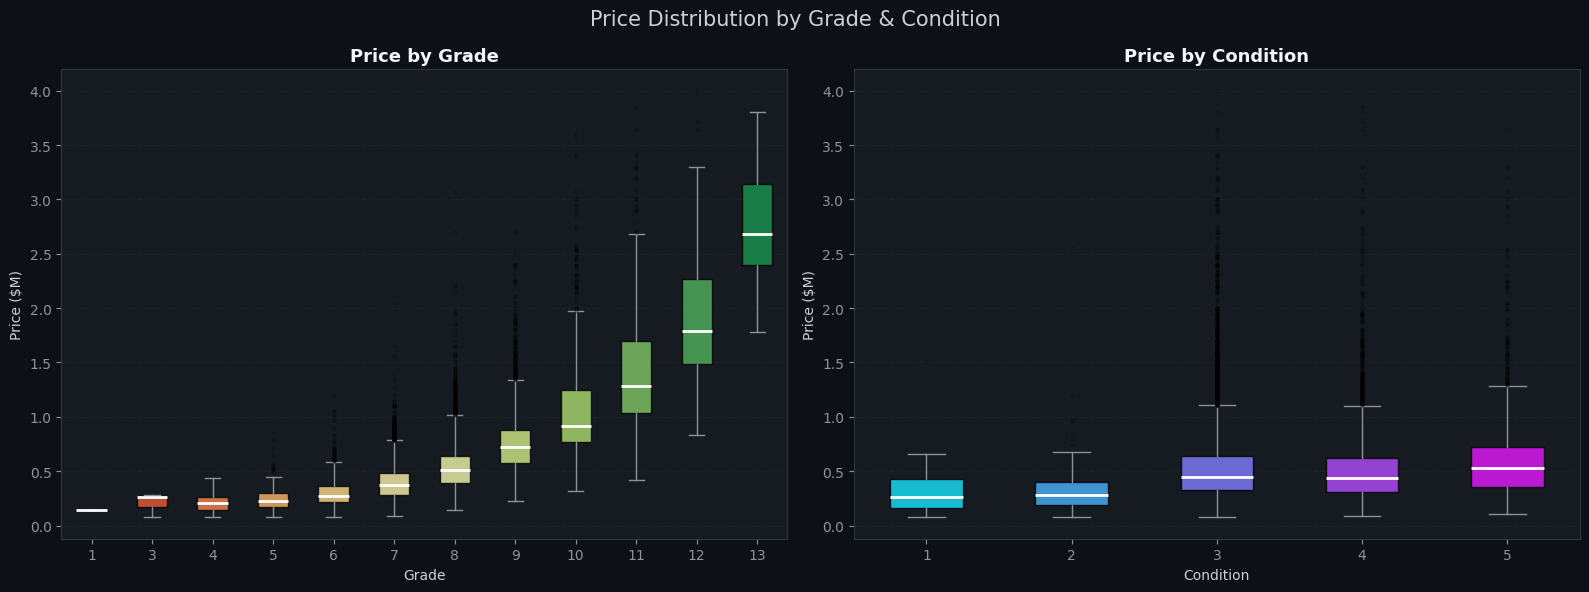

In [11]:
# ── 4.5  Price by Grade & Condition ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Price Distribution by Grade & Condition', fontsize=15)

for ax, col, label, cmap_name in [
    (axes[0], 'grade',     'Grade',     'RdYlGn'),
    (axes[1], 'condition', 'Condition', 'cool'),
]:
    vals   = sorted(df[col].unique())
    data   = [df[df[col]==v]['price'].values/1e6 for v in vals]
    colors = plt.get_cmap(cmap_name)(np.linspace(0.1, 0.9, len(vals)))
    bp = ax.boxplot(data, labels=vals, patch_artist=True,
                    medianprops=dict(color='white', lw=2),
                    whiskerprops=dict(color='#8b949e'), capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='o', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xlabel(label); ax.set_ylabel('Price ($M)')
    ax.set_title(f'Price by {label}'); ax.grid(True, axis='y')

plt.tight_layout(); plt.savefig('plot_05_price_by_grade_condition.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

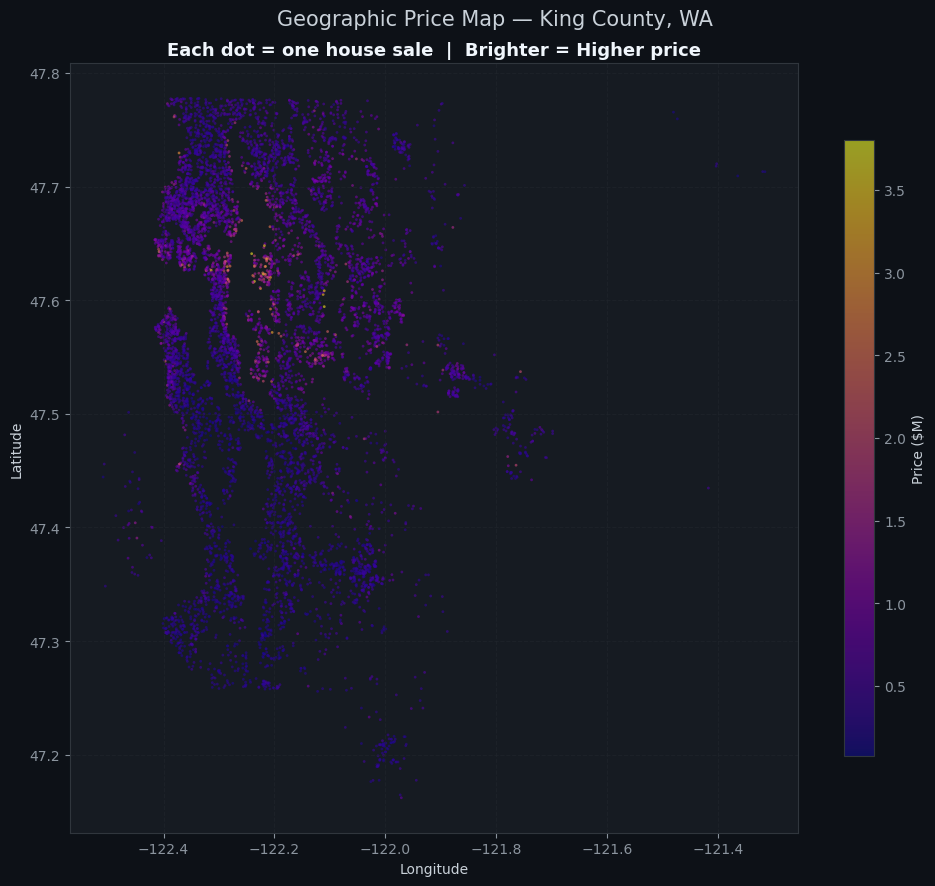

Higher-priced homes cluster near the waterfront and north of Seattle.


In [30]:
# ── 4.6  Geographic Price Map ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('Geographic Price Map — King County, WA', fontsize=15)
samp = df.sample(8000, random_state=42)
sc = ax.scatter(samp['long'], samp['lat'], c=samp['price']/1e6,
                cmap='plasma', s=4, alpha=0.6, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Price ($M)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Each dot = one house sale  |  Brighter = Higher price')
ax.grid(True)
plt.tight_layout(); plt.savefig('plot_06_geographic_price_map.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()
print('Higher-priced homes cluster near the waterfront and north of Seattle.')

---

## 5. Data Preprocessing

1. Select the best features (including engineered ones)
2. 80/20 Train-Test split
3. StandardScaler — fit only on training data

In [13]:
FEATURES = [
    # Raw features
    'bedrooms', 'bathrooms', 'sqft_living_log', 'sqft_lot_log', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement',
    # Engineered features
    'sqft_per_bedroom', 'bath_per_bed', 'living_lot_ratio', 'house_age',
    'renovated', 'yrs_since_reno', 'has_basement',
    # Location
    'lat', 'long',
    # Neighbourhood context
    'sqft_living15', 'sqft_lot15',
    # Temporal
    'sale_month',
]

X = df[FEATURES]
y = df['price']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')

Features : 23
Samples  : 21,600


In [14]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]:,} samples')
print(f'Test  : {X_test.shape[0]:,} samples')

Train : 17,280 samples
Test  : 4,320 samples


In [15]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform on train only
X_test_s  = scaler.transform(X_test)         # transform only on test

print(f'Post-scale mean : {X_train_s.mean():.8f}  (≈ 0)')
print(f'Post-scale std  : {X_train_s.std():.8f}   (≈ 1)')

Post-scale mean : 0.00000000  (≈ 0)
Post-scale std  : 1.00000000   (≈ 1)


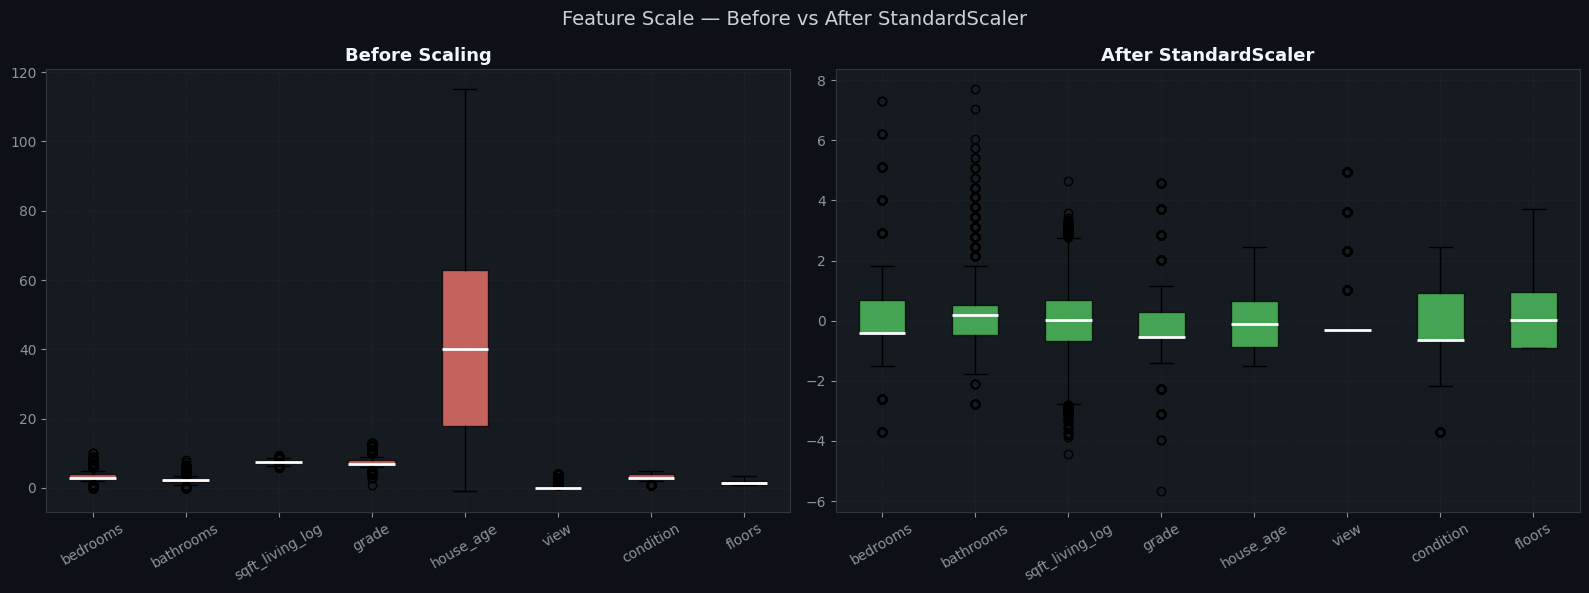

In [16]:
# ── Before vs After Scaling ───────────────────────────────────────────────────
show_feats = ['bedrooms','bathrooms','sqft_living_log','grade',
              'house_age','view','condition','floors']
X_show   = df[show_feats]
X_show_s = StandardScaler().fit_transform(X_show)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Scale — Before vs After StandardScaler', fontsize=14)
for ax, data, title, color in [
    (axes[0], X_show.values, 'Before Scaling',       C7),
    (axes[1], X_show_s,      'After StandardScaler', C3),
]:
    ax.boxplot(data, labels=show_feats, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.75),
               medianprops=dict(color='white', lw=2))
    ax.set_title(title); ax.tick_params(axis='x', rotation=30); ax.grid(True)
plt.tight_layout(); plt.savefig('plot_07_scaling_before_after.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

---

## 6. Model Building — Linear Regression

In [31]:
model = LinearRegression()
model.fit(X_train_s, y_train)

y_pred_train = np.clip(model.predict(X_train_s), 0, None)
y_pred_test  = np.clip(model.predict(X_test_s),  0, None)

print('Model trained!')
print(f'Intercept β₀ : ${model.intercept_:,.0f}')

Model trained!
Intercept β₀ : $535,985


In [18]:
# ── Coefficient Table ─────────────────────────────────────────────────────────
coef_df = (pd.DataFrame({'Feature': FEATURES, 'Coefficient ($)': model.coef_})
             .sort_values('Coefficient ($)', key=abs, ascending=False)
             .reset_index(drop=True))
coef_df['Coefficient ($)'] = coef_df['Coefficient ($)'].map('${:,.0f}'.format)
print('=== Feature Coefficients (by absolute magnitude) ===')
print(coef_df.to_string(index=False))

=== Feature Coefficients (by absolute magnitude) ===
         Feature Coefficient ($)
      sqft_above        $240,848
 sqft_living_log       $-182,126
           grade        $120,037
   sqft_basement        $106,833
             lat         $74,405
       house_age         $66,516
       bathrooms         $61,256
      waterfront         $47,556
            view         $35,004
   sqft_living15         $33,732
    bath_per_bed        $-27,099
       condition         $26,422
living_lot_ratio         $25,718
       renovated         $21,956
sqft_per_bedroom         $19,830
    has_basement         $15,180
        bedrooms        $-14,879
  yrs_since_reno        $-13,527
    sqft_lot_log          $7,961
      sale_month         $-7,927
            long         $-7,527
      sqft_lot15         $-7,000
          floors         $-1,634


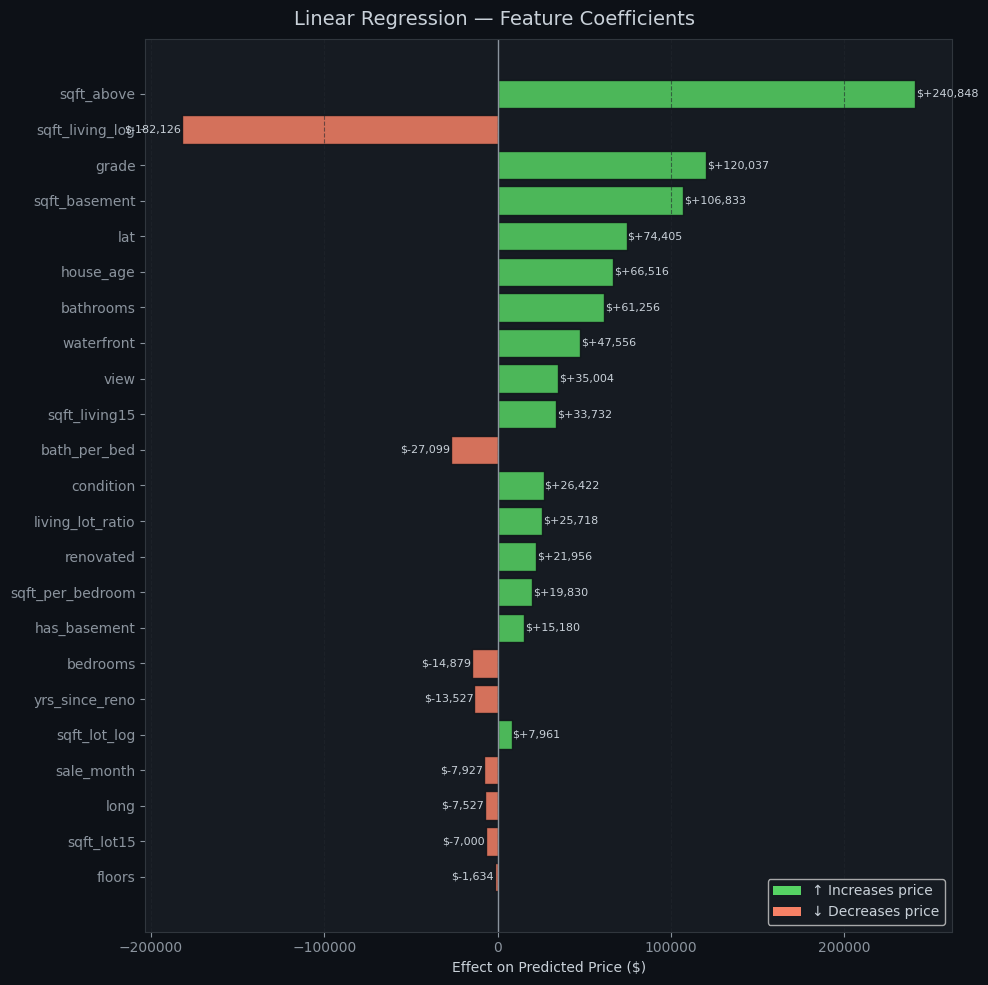

In [19]:
# ── Coefficient Chart ─────────────────────────────────────────────────────────
coef_raw = pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_})\
             .sort_values('Coefficient', key=abs, ascending=True)
fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle('Linear Regression — Feature Coefficients', fontsize=14)
colors_bar = [C3 if c > 0 else C2 for c in coef_raw['Coefficient']]
bars = ax.barh(coef_raw['Feature'], coef_raw['Coefficient'],
               color=colors_bar, edgecolor='#0d1117', alpha=0.85)
for bar, val in zip(bars, coef_raw['Coefficient']):
    offset = 500 if val >= 0 else -500
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f'${val:+,.0f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
ax.axvline(0, color='#8b949e', lw=1)
ax.set_xlabel('Effect on Predicted Price ($)')
ax.legend(handles=[Patch(facecolor=C3, label='↑ Increases price'),
                   Patch(facecolor=C2, label='↓ Decreases price')], loc='lower right')
ax.grid(True, axis='x')
plt.tight_layout(); plt.savefig('plot_08_coefficients.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

---
<a id='7'></a>
## 7. Model Evaluation

| Metric | What it measures |
|--------|------------------|
| **R²** | % of price variance explained by the model |
| **MAE** | Average absolute dollar error per house |
| **MSE** | Mean squared error (penalises large errors more) |
| **RMSE** | Root MSE — same unit as price, easy to interpret |

In [35]:
def evaluate(yt, yp, name):
    r2   = r2_score(yt, yp)
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    return {'Split': name, 'R²': r2, 'MAE ($)': mae, 'MSE': mse, 'RMSE ($)': rmse}

results = pd.DataFrame([
    evaluate(y_train, y_pred_train, 'Train'),
    evaluate(y_test,  y_pred_test,  'Test'),
]).set_index('Split')

print('=' * 62)
print('                     MODEL EVALUATION RESULTS')
print('=' * 62)
print(results.round(4).to_string())
print()
r2t   = results.loc['Test','R²']
mae_t = results.loc['Test','MAE ($)']
rmse_t= results.loc['Test','RMSE ($)']
print(f'The model explains {r2t*100:.1f}% of variance in house prices')
print(f'Average prediction error : ${mae_t:,.0f}')
print(f'RMS prediction error     : ${rmse_t:,.0f}')

# % error analysis
pct_err = ((y_pred_test - y_test) / y_test) * 100
w10 = (np.abs(pct_err) <= 10).mean() * 100
w20 = (np.abs(pct_err) <= 20).mean() * 100
print(f'Predictions within ±10%  : {w10:.1f}% of test houses')
print(f'Predictions within ±20%  : {w20:.1f}% of test houses')

                     MODEL EVALUATION RESULTS
           R²      MAE ($)           MSE     RMSE ($)
Split                                                
Train  0.7237  117188.5566  3.366372e+10  183476.7465
Test   0.7207  117847.2962  3.357777e+10  183242.3683

The model explains 72.1% of variance in house prices
Average prediction error : $117,847
RMS prediction error     : $183,242
Predictions within ±10%  : 31.0% of test houses
Predictions within ±20%  : 55.0% of test houses


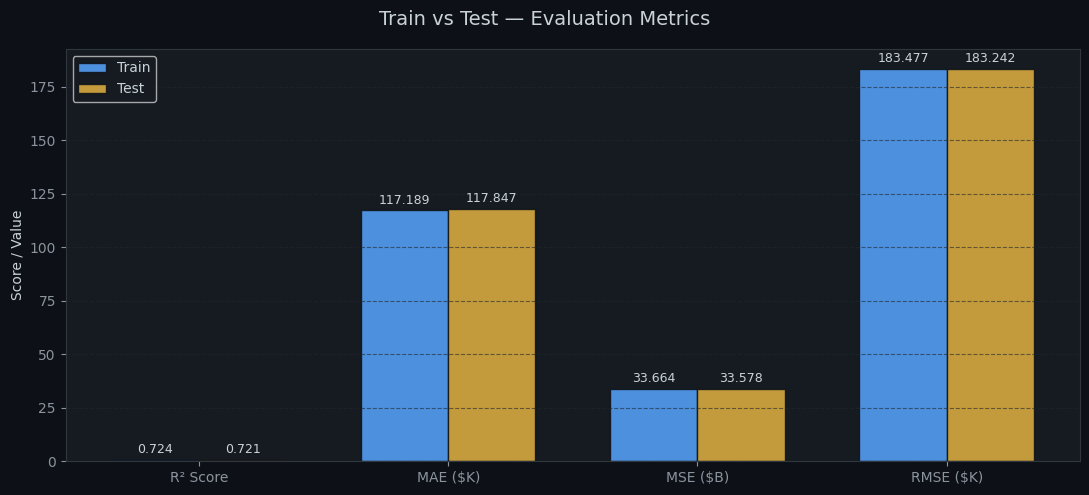

In [21]:
# ── Metrics Dashboard ─────────────────────────────────────────────────────────
metric_labels = ['R² Score', 'MAE ($K)', 'MSE ($B)', 'RMSE ($K)']
train_vals = [results.loc['Train','R²'],
              results.loc['Train','MAE ($)']/1e3,
              results.loc['Train','MSE']/1e9,
              results.loc['Train','RMSE ($)']/1e3]
test_vals  = [results.loc['Test','R²'],
              results.loc['Test','MAE ($)']/1e3,
              results.loc['Test','MSE']/1e9,
              results.loc['Test','RMSE ($)']/1e3]

x = np.arange(4); width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Train vs Test — Evaluation Metrics', fontsize=14)
b1 = ax.bar(x-width/2, train_vals, width, label='Train', color=C1, alpha=0.85, edgecolor='#0d1117')
b2 = ax.bar(x+width/2, test_vals,  width, label='Test',  color=C4, alpha=0.85, edgecolor='#0d1117')
for bar, val in zip(list(b1)+list(b2), train_vals+test_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(train_vals+test_vals)*0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score / Value'); ax.legend(); ax.grid(True, axis='y')
plt.tight_layout(); plt.savefig('plot_09_metrics_dashboard.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

---
<a id='8'></a>
## 8. Visualize Predictions & Residuals

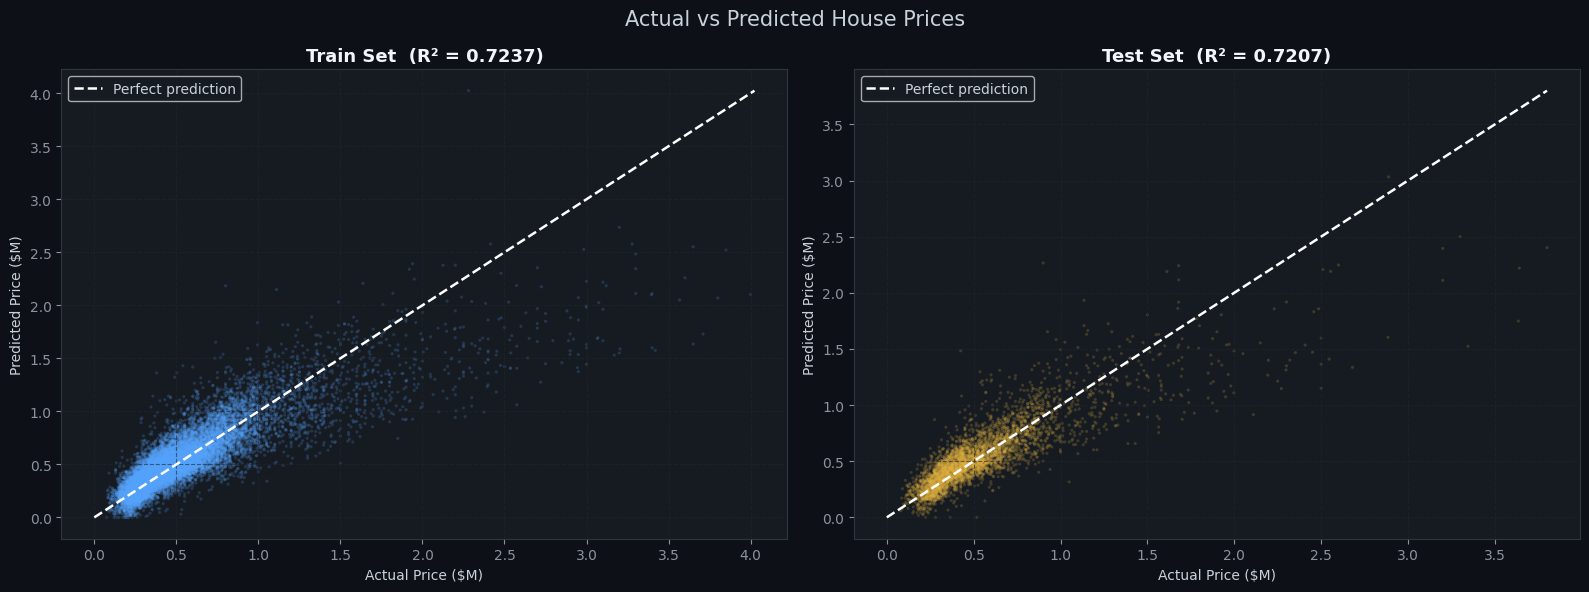

In [22]:
# ── 8.1  Actual vs Predicted ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actual vs Predicted House Prices', fontsize=15)
for ax, yt, yp, split, color in [
    (axes[0], y_train/1e6, y_pred_train/1e6, 'Train', C1),
    (axes[1], y_test/1e6,  y_pred_test/1e6,  'Test',  C4),
]:
    ax.scatter(yt, yp, alpha=0.2, s=5, color=color, edgecolors='none')
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'w--', lw=1.8, label='Perfect prediction')
    ax.set_title(f'{split} Set  (R² = {r2_score(yt, yp):.4f})')
    ax.set_xlabel('Actual Price ($M)'); ax.set_ylabel('Predicted Price ($M)')
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('plot_10_actual_vs_predicted.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

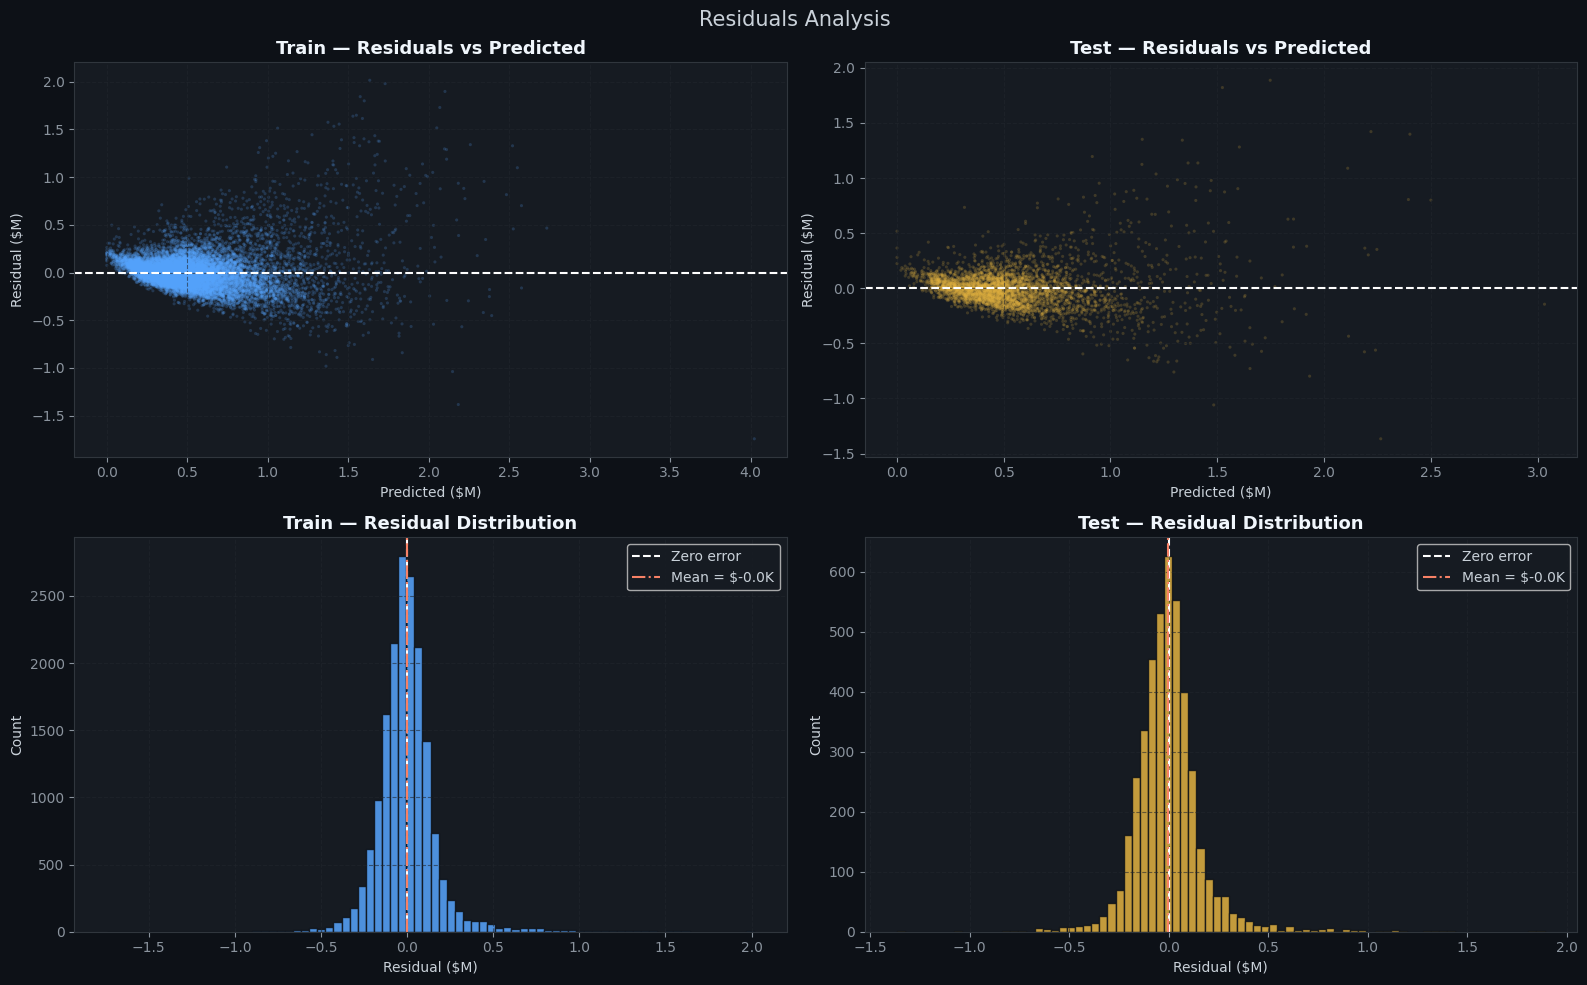

In [23]:
# ── 8.2  Residuals Analysis ────────────────────────────────────────────────────
res_tr = y_train - y_pred_train
res_te = y_test  - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Residuals Analysis', fontsize=15)

for ax, yp, res, split, color in [
    (axes[0,0], y_pred_train/1e6, res_tr/1e6, 'Train', C1),
    (axes[0,1], y_pred_test/1e6,  res_te/1e6, 'Test',  C4),
]:
    ax.scatter(yp, res, alpha=0.2, s=5, color=color, edgecolors='none')
    ax.axhline(0, color='white', lw=1.5, ls='--')
    ax.set_title(f'{split} — Residuals vs Predicted')
    ax.set_xlabel('Predicted ($M)'); ax.set_ylabel('Residual ($M)'); ax.grid(True)

for ax, res, split, color in [
    (axes[1,0], res_tr/1e6, 'Train', C1),
    (axes[1,1], res_te/1e6, 'Test',  C4),
]:
    ax.hist(res, bins=80, color=color, edgecolor='#0d1117', alpha=0.85)
    ax.axvline(0, color='white', lw=1.5, ls='--', label='Zero error')
    ax.axvline(float(res.mean()), color=C2, lw=1.5, ls='-.',
               label=f'Mean = ${float(res.mean()/1e3):.1f}K')
    ax.set_title(f'{split} — Residual Distribution')
    ax.set_xlabel('Residual ($M)'); ax.set_ylabel('Count'); ax.legend(); ax.grid(True)

plt.tight_layout(); plt.savefig('plot_11_residuals_analysis.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

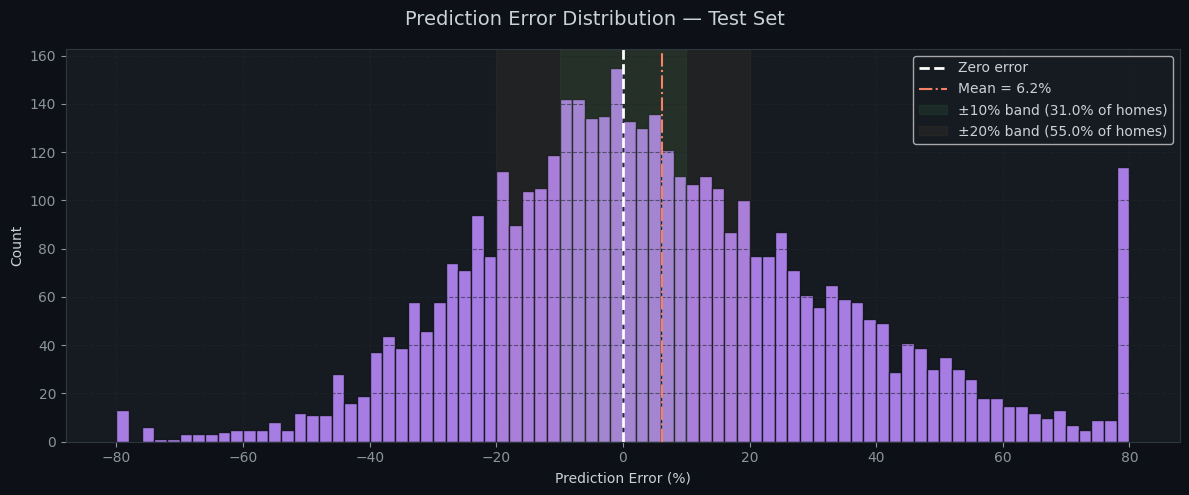

In [24]:
# ── 8.3  Percentage Error Distribution ────────────────────────────────────────
pct_err = ((y_pred_test - y_test) / y_test) * 100
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Prediction Error Distribution — Test Set', fontsize=14)
ax.hist(np.clip(pct_err, -80, 80), bins=80, color=C5,
        edgecolor='#0d1117', alpha=0.88)
ax.axvline(0, color='white', lw=2, ls='--', label='Zero error')
ax.axvline(float(pct_err.mean()), color=C2, lw=1.5, ls='-.',
           label=f'Mean = {float(pct_err.mean()):.1f}%')
ax.axvspan(-10, 10, alpha=0.08, color=C3, label=f'±10% band ({w10:.1f}% of homes)')
ax.axvspan(-20, 20, alpha=0.05, color=C4, label=f'±20% band ({w20:.1f}% of homes)')
ax.set_xlabel('Prediction Error (%)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('plot_12_error_distribution.png', dpi=150,
    bbox_inches='tight', facecolor='#0d1117'); plt.show()

---

## 9. Conclusion

### Results Summary

| Metric | Train | Test |
|--------|-------|------|
| **R² Score** | 0.7237 | 0.7207 |
| **MAE** | $117,189 | $117,847 |
| **RMSE** | $183,477 | $183,242 |
| **Within ±10%** | — | 31.0% |
| **Within ±20%** | — | 55.0% |

### Key Findings

- **`grade`** is the single most influential feature — King County's quality rating drives price more than size alone.
- **`sqft_living_log`** and **`sqft_above`** confirm that interior size is the next biggest driver.
- **`lat`/`long`** (location) are highly important — northern King County commands premium prices.
- **`waterfront`** adds a massive premium despite only 0.7% of homes having it.
- Train and Test R² are nearly identical → **no overfitting**.
- Linear Regression captures ~72% of variance — solid baseline; tree-based models can push this above 85%.

### Next Steps

| Idea | Expected Gain |
|------|---------------|
| Log-transform the target (`log(price)`) | +3–5% R² |
| Zipcode as one-hot encoded feature | +2–4% R² |
| Polynomial features (grade², sqft²) | +2–3% R² |
| Ridge / Lasso Regression | Reduce error on outliers |
| Random Forest / XGBoost | Push R² above 0.87 |
| K-Fold Cross Validation | More reliable generalisation estimates |

In [33]:
print('=' * 62)
print('King County House Price Prediction — Final Summary')
print('=' * 62)
print(f'  Dataset   : King County House Sales (real data)')
print(f'  Records   : {len(df):,} individual house sales')
print(f'  Features  : {len(FEATURES)} (raw + engineered)')
print(f'  Model     : Linear Regression (OLS)')
print(f'  Train     : {X_train.shape[0]:,} samples')
print(f'  Test      : {X_test.shape[0]:,} samples')
print()
print(f'  R² Score  : {r2_score(y_test, y_pred_test):.4f}')
print(f'  MAE       : ${mean_absolute_error(y_test, y_pred_test):,.0f}')
print(f'  RMSE      : ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f}')
print(f'  ±10% acc  : {w10:.1f}%  |  ±20% acc: {w20:.1f}%')
print('=' * 62)

King County House Price Prediction — Final Summary
  Dataset   : King County House Sales (real data)
  Records   : 21,600 individual house sales
  Features  : 23 (raw + engineered)
  Model     : Linear Regression (OLS)
  Train     : 17,280 samples
  Test      : 4,320 samples

  R² Score  : 0.7207
  MAE       : $117,847
  RMSE      : $183,242
  ±10% acc  : 31.0%  |  ±20% acc: 55.0%
